In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from scipy.integrate import quad

import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import truncnorm
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

import torch
import torch.nn as nn
import torch.optim as optim
#import torchvision
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
#import torchinfo

import warnings
import os
from copy import deepcopy

import plotting
import dataset_fctns
import modelling_fctns
from ML_fctns import *

from datetime import datetime
from dateutil.relativedelta import relativedelta
#from suntimes import SunTimes  
import sys
sys.path.append("C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\optimisation_experiments")
#from optimise_GDD_fctns import *
from nn_response_fctns import *

import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.io.shapereader as shpreader

C:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:35: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


In [2]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
                             index_cols = ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year']): 
    #Change index_cols to ['year', 'Stations_id'] if using DE dataset
    len_index_cols = len(index_cols)
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 10, 3)#, x[4], x[5])#x[2]
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'Convolved_vary_spread':
        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + index_cols]#.copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm + 'dev'] = t_dev
    else:
        ds_for_model.loc[:, [colm + 'dev' for colm in driver_columns]] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model[[colm + 'dev' for colm in driver_columns] + index_cols].values.T
    column_names = [np.array([f'modelled time to {phase}' for phase in phase_list]+ index_cols)]
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        #print(model_dev_time_series[:-len_index_cols, obs_index])#.astype(np.float64))
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-len_index_cols, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, *[[model_dev_time_series[-(k + 1)]] for k in reversed(range(len_index_cols))]], axis=0)
    #print(column_names)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names[0])
    #print(ds.columns.to_list(), phase_dates_array.columns.to_list())
    comparison_array = ds.T.drop_duplicates().T.merge(phase_dates_array, how='left', on=index_cols).dropna(how='all')
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array

In [3]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [4]:
def split_ds_by_AEZ2(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4, 10])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    ds_city = ds.loc[ds['AEZ'].isin([32])].groupby(['Stations_id', 'year']).head(2)
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum humid high: {len(ds_humid_high)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [5]:
def split_ds_by_AEZ5(ds):
    ds_semiarid_low = ds.loc[ds['AEZ'].isin([1])]#.groupby(['Stations_id', 'year']).head(2)
    ds_arid_low = ds.loc[ds['AEZ'].isin([26, 29])]#.groupby(['Stations_id', 'year']).head(2)
    ds_subhumid_low = ds.loc[ds['AEZ'].isin([2])]#.groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([3])]#.groupby(['Stations_id', 'year']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4])]#.groupby(['Stations_id', 'year']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5])]#.groupby(['Stations_id', 'year']).head(2)
    ds_cool = ds.loc[ds['AEZ'].isin([10, 11, 14])]#.groupby(['Stations_id', 'year']).head(2)
    print(#f'\nnum cool: {len(ds_cool)}',
        f'\nnum semiarid low: {len(ds_semiarid_low)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum subhumid low: {len(ds_subhumid_low)}',
        f'\nnum subhumid high: {len(ds_humid_high)}')
    ds_dict = {#'cool': ds_cool,
               'semiarid low': ds_semiarid_low,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'subhumid low': ds_subhumid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [6]:
def local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE, lower_bounds = [0.05, 4, 20, 20, 35], upper_bounds = [1, 12, 35, 35, 60], #ds
              great_threshold = 13, response_type = 'Trapezoid', phase_list = ['yellow ripeness'],
              method = 'trust-constr', modified_cost = False, thresholds = [100], growing_period_length = 185,
              maxiter = 50, split = True, CCNN_split = False, test_size = 0.5, random_state=1, itr = 0.5, bias_term = False):
    #if split:
    #    train, test = train_test_split(ds, test_size=test_size, random_state = random_state)
    #    #train_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\temp_CCNN_training.csv')
    #elif CCNN_split:
    #    test_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\compare_CCNN_results.csv')
    #    train_indices = train_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test_indices = test_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    complement_indices = ds.index.difference(test.index)
    #
    #    # Filter df2 to keep only the rows with the complement indices
    #    train = ds.loc[complement_indices]
    #    #train = pd.merge(ds, train_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #else:
    #    train = ds
    #    test = ds
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[4] - x[3]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0],
                                                [0, 0, -1, 1, 0],
                                                [0, 0, 0, -1, 1]])}
        constraints = scipy.optimize.LinearConstraint([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0], [0, 0, 0, -1, -1]], [0, 0, 0], [np.inf, np.inf, np.inf])
    elif response_type == 'Wang' or response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Spline':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2],
                                                x[3]]),
                    'jac' : lambda x: np.array([[0 for count in range(20)],
                                                [0 for count in range(20)]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0 for count in range(20)], [0 for count in range(20)]]),lb= [-1, -1], ub=[1000, 1000])
    elif response_type == 'multi_phase':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[6] - x[5],
                                                x[7] - x[6]]
                                                ),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, -1, 1, 0],
                                                [0, 0, -1, 1, 0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    bounds = scipy.optimize.Bounds(lb=lower_bounds, ub = upper_bounds)
    x0 = np.array([1, 4, 25, 35, 45])
    final_mins = []
    for x0 in x1s:
        if method == 'trust-constr':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list, 
                                                                         new_unfinished_penalisation=modified_cost, 
                                                                         growing_period_length = growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'trust-constr',#'COBYQA',
                                    jac='3-point',#
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', #jac='3-point',#[x0/1000 for x0 in 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#
                                    constraints=[constraints],
                                    options={'verbose': 1, 'initial_tr_radius': itr, 'xtol':1e-7, 'maxiter':maxiter},# ,'gtol':1e-7, 'finite_diff_rel_step': 0.05
                                    bounds=bounds, tol=1e-9)
        elif method == 'SLSQP':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'SLSQP',
                                    #jac = '3-point',
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#jac='3-point',#
                                    constraints=[ineq_cons],
                                    options={'disp': 3, 'maxiter':maxiter, 'ftol': 1e-16},
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Nelder-Mead':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Nelder-Mead',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Powell':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Powell',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)
        print(x0, res.x, x0 - res.x)
        RMSE = error_fctn(res.x, test, 't2m', response_type = response_type, phase_list = phase_list, thresholds = thresholds, growing_period_length = growing_period_length)
        #print('R^2: ', r2_score(c_array[f'observed time to {only_phase}'], c_array[f'modelled time to {only_phase}']))
        print('RMSE at opt on test set: ', RMSE)
        print('R^2:', 1 - (RMSE**2/(test[f'observed time to {only_phase}'].var()*((len(test) - 1)/len(test)))))
        final_mins.append(res.x)
    return final_mins, res, train, test

In [7]:
def split_ds_by_AEZ2(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])].groupby(['Stations_id', 'Referenzjahr']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])].groupby(['Stations_id', 'Referenzjahr']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4, 10])].groupby(['Stations_id', 'Referenzjahr']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5, 11, 14])].groupby(['Stations_id', 'Referenzjahr']).head(2)
    ds_city = ds.loc[ds['AEZ'].isin([32])].groupby(['Stations_id', 'Referenzjahr']).head(2)
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum humid high: {len(ds_humid_high)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [8]:
def K_fold_crossval(k_folds, input_dataset, model_class, 
                    epochs, bs, model_args, savename_prefix = 'KFold', 
                    freeze_params = False, loss = 'NLL', 
                    CNN=False, bce=False, lr = 0.01, MMD=False, 
                    n_channels = 4, DTF = False, obs_method = False, 
                    custom_loss = None, year_split = False, 
                    year_folds = [], GDD_init = None,
                    index_cols = ['Stations_id', 'year', 'Management', 'vargroup']):
    ## LSTM_args: input_dim, hidden_dim, num_layers, output_dim
    # Initialize the k-fold cross validation
    #index_cols = ['Stations_id', 'year', 'Management', 'vargroup']#['year', 'Stations_id']
    ## LSTM_args: input_dim, hidden_dim, num_layers, output_dim
    # Initialize the k-fold cross validation
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = 1)
    # Loop through each fold
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []
    if year_split:
        splitter = year_folds
    else:
        statyear = input_dataset[index_cols].drop_duplicates()
        splitter = kf.split(statyear)
    for fold, traintest_idx in enumerate(splitter):
        print(f"Fold {fold + 1}")
        if year_split:
            X_tensor, y_tensor = train_ds
            train_dl, val_dl = train_test_dl_by_year(X_tensor, y_tensor, test_years = traintest_idx, year_column = -2, bs = bs, n_channels = 8)
        # Define the data loaders for the current fold
        else:
            train_idx, test_idx = traintest_idx
            train_statyear = statyear.iloc[train_idx]
            test_statyear = statyear.iloc[test_idx]
            train = input_dataset.merge(train_statyear, on=index_cols, how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
            test = input_dataset.merge(test_statyear, on=index_cols, how = 'inner')
            lengths.append(len(test))
            X_tensor_train, y_tensor_train = ML_tensor_from_ds(train)
            X_tensor_test, y_tensor_test = ML_tensor_from_ds(test)
            #print(len(ds), X_tensor_test.shape, X_tensor_train.shape)
            train_ds, ___ = train_test_ds_from_tensors(X_tensor_train, y_tensor_train, train_proportion=1)
            val_ds, ___ = train_test_ds_from_tensors(X_tensor_test, y_tensor_test, train_proportion=1)
            train_dl = DataLoader(
                dataset=train_ds,
                batch_size=bs,
            )
            val_dl = DataLoader(
                dataset=val_ds,
                batch_size=bs,
            )
        # Initialize the model and optimizer
        model = model_class(*model_args).to(device)
        if GDD_init is not None:
            if GDD_init == 'calculate':
                x1s = [np.array([0.5, 8, 23, 39])]
                print('calculate optimum GDD params')
                fm = local_opt(x1s, 
                               train.loc[:, [f't2m at day {n}' for n in range(160)] + ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year', 'observed time to beginning of flowering']], 
                               test.loc[:, [f't2m at day {n}' for n in range(160)] + ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year', 'observed time to beginning of flowering']],
                            lower_bounds = [0.01, 7, 20, 38.5], upper_bounds = [5, 11, 31, 40],
                            great_threshold = 13, response_type = 'Wang',
                            phase_list = ['beginning of flowering'],
                            method='Nelder-Mead',
                            thresholds = [20], growing_period_length=160,
                            test_size = 0.02, maxiter=50)
                GDD_params = fm[0][0]
                #print('why is it doing this fuynny c?')
                #print(*GDD_params, GDD_params)
                model = initialise_as_GDD(model, *GDD_params, n_channels=5)
            elif GDD_init == 'just rate':
                x_0 = scipy.optimize.minimize_scalar(lambda x: run_GDD_and_get_RMSE([x] + [9.3, 25, 39.2], train.loc[:, [f't2m at day {n}' for n in range(160)] + ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year', 'observed time to beginning of flowering']], 
                                                                                    't2m', 
                                                                                response_type='Wang', phase_list = ['beginning of flowering'], 
                                                                                thresholds = [20], growing_period_length = 160),
                                                bounds = (0.01, 5),
                                                method='bounded',
                                                options = {'disp': 3})
                GDD_params = [x_0.x, 9.3, 25, 39.2]
                print(GDD_params)
                model = initialise_as_GDD(model, *GDD_params, n_channels=5)
            else:
                GDD_params = GDD_init[fold]#[0.31621224, 7.37066436, 22.88481424, 39.40562477]
                print(GDD_params)
                model = initialise_as_GDD(model, *GDD_params, n_channels=5)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        if loss == 'NLL':
            criterion = nn.NLLLoss()
        elif loss == 'BCE':
            criterion = nn.BCELoss()
        elif loss == 'MSE':
            criterion = custom_loss()
        # Train the model on the current fold
        if freeze_params:
            for param in [model.u0, model.u1, model.u2, model.u3, model.p0]:
                param.requires_grad = False

        model_loss = fit_for_kf(epochs, model, criterion, optimizer, train_dl, val_dl, save_name = savename_prefix + str(fold + 1), CNN=CNN, bce=bce, verbose=True)
        loss_values.append(model_loss)

        #Now look at stats for model:
        model_dir = 'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\ML_algorithms\\saved_models\\'
        model_path = os.path.join(model_dir, savename_prefix + str(fold + 1) + ".pt")
        checkpoint = torch.load(model_path, weights_only=True)
        TS_model = model_class(*model_args).to(device)
        TS_model.load_state_dict(checkpoint['model_state_dict'])
        comparison_frame = get_comparison_frame(savename_prefix + str(fold + 1), TS_model, val_dl, bce=bce, CNN=CNN, MMD=MMD, n_channels = n_channels, DTF = DTF, obs_method = obs_method)
        comparison_frame['Error'] = comparison_frame['observed'] - comparison_frame['fitted']

        bias_model = 0#comparison_frame['Error'].mean()
        RMSE = np.sqrt(np.mean((comparison_frame['Error'] - bias_model)**2))
        SSE = np.sum((comparison_frame['Error'] - bias_model)**2)
        STD = comparison_frame['fitted'].std() 
        Corr = comparison_frame['observed'].corr(comparison_frame['fitted'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_frame['Error'].min())
        LQs.append(comparison_frame['Error'].quantile(0.25))
        Medians.append(comparison_frame['Error'].median())
        UQs.append(comparison_frame['Error'].quantile(0.75))
        Maxs.append(comparison_frame['Error'].max())

        rsquared = r2_score(comparison_frame['observed'], comparison_frame['fitted'])
        bias = comparison_frame['observed'].mean() - comparison_frame['fitted'].mean()
        variance_modelled = comparison_frame[f'fitted'].var()
        variance_observed = comparison_frame['observed'].var()
        
        R2s.append(rsquared)
        Biases.append(bias)
        Variances.append(variance_modelled)
        obsvars.append(variance_observed)

        if fold == 0:
            comparison_frame_full = comparison_frame
        else:
            comparison_frame_full = pd.concat((comparison_frame, comparison_frame_full))

    return comparison_frame_full, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars

In [9]:
def K_fold_transfer(k_folds, ds, model_class, 
                    savename, epochs, bs, model_args, 
                    lr = 0.01, savename_prefix = 'KFold',
                    loss = 'NLL', 
                    CNN=False, bce=False, custom_loss = None, 
                    MMD = False, DTF = False, obs_method = False,
                    transfer_method = 'all wang', verbose = False,
                    index_cols = ['Stations_id', 'year', 'Management', 'vargroup']):
    ## LSTM_args: input_dim, hidden_dim, num_layers, output_dim
    # Initialize the k-fold cross validation
    # Loop through each fold
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = 1)
    statyear = ds[index_cols].drop_duplicates()
    for fold, (train_idx, test_idx) in enumerate(kf.split(statyear)):
        print('Fold: ', fold+1)
        train_statyear = statyear.iloc[train_idx]
        test_statyear = statyear.iloc[test_idx]
        train = ds.merge(train_statyear, on=index_cols, how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
        test = ds.merge(test_statyear, on=index_cols, how = 'inner')
        lengths.append(len(test))
        #print(f"Fold {fold + 1}")
        X_tensor_train, y_tensor_train = ML_tensor_from_ds(train)
        X_tensor_test, y_tensor_test = ML_tensor_from_ds(test)
        #print(len(ds), X_tensor_test.shape, X_tensor_train.shape)
        train_ds, ___ = train_test_ds_from_tensors(X_tensor_train, y_tensor_train, train_proportion=1)
        val_ds, ___ = train_test_ds_from_tensors(X_tensor_test, y_tensor_test, train_proportion=1)
        # Define the data loaders for the current fold
        train_dl = DataLoader(
            dataset=train_ds,
            batch_size=bs,
        )
        val_dl = DataLoader(
            dataset=val_ds,
            batch_size=bs,
        )
        model = model_class(*model_args).to(device)
        model_dir = 'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\ML_algorithms\\saved_models\\'
        model_path = os.path.join(model_dir, savename + ".pt")
        checkpoint = torch.load(model_path, weights_only=True)
        model.load_state_dict(checkpoint['model_state_dict'])
        for param in model.parameters():
            param.requires_grad = False
        if transfer_method == 'all wang':
            for param in [model.u0, model.u1, model.u2, model.u3]:
                param.requires_grad = True
        elif transfer_method == 'just rate':
            for param in [model.u4]:
                param.requires_grad = True
        elif transfer_method == 'wang and first':
            for param in [param for param in model.input_layer.parameters()] + [model.u0, model.u1, model.u2, model.u3]:
                param.requires_grad = True
        
        optimizer = optim.Adam(model.parameters(), lr=lr)
        if loss == 'NLL':
            criterion = nn.NLLLoss()
        elif loss == 'BCE':
            criterion = nn.BCELoss()
        elif loss == 'MSE':
            criterion = custom_loss
        # Train the model on the current fold

        #for param in [model.u0, model.u1, model.u2, model.u3, model.p0]:
        #    print(param.requires_grad, param.shape)
        model_loss = fit_for_kf(epochs, model, criterion, optimizer, train_dl, val_dl, save_name = savename_prefix + str(fold + 1), CNN=CNN, bce=bce, plot_opt=False, verbose=verbose)
        loss_values.append(model_loss)

        #Now look at stats for model:
        model_dir = 'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\ML_algorithms\\saved_models\\'
        model_path = os.path.join(model_dir, savename_prefix + str(fold + 1) + ".pt")
        checkpoint = torch.load(model_path, weights_only=True)
        TS_model = model_class(*model_args).to(device)
        TS_model.load_state_dict(checkpoint['model_state_dict'])
        # Now convert to days and get R^2 to compare to other models
        list_logs = []
        list_GDD_logs = []
        list_observed = []
        for xb, yb in val_dl:
            with torch.no_grad():
                if CNN:
                    if MMD:
                        list_logs.append(TS_model(xb)[0])
                        list_GDD_logs.append(TS_model(xb, no_nn=True)[0])
                    else:
                        list_logs.append(TS_model(xb))
                        list_GDD_logs.append(TS_model(xb, no_nn=True))
                else:
                    list_logs.append(TS_model(xb.transpose(1, 2)))
                    list_GDD_logs.append(TS_model(xb.transpose(1, 2), no_nn=True))
                #print(TS_model(xb.transpose(1, 2)))
            list_observed.append(yb)
        logs = torch.squeeze(torch.cat(list_logs))
        GDD_logs = torch.squeeze(torch.cat(list_GDD_logs))
        observed = torch.cat(list_observed)
        #print(logs.shape, torch.cat(list_logs, dim=0).shape)
        if not(DTF):
            if bce:
                fitted = torch.round(logs)
                fitted_GDD = torch.round(GDD_logs)
            else:
                fitted = torch.argmax(logs, dim=2)
                fitted_GDD = torch.argmax(GDD_logs, dim=2)
        if DTF:
            logs = torch.round(logs)
            observed_days = mindex_at_0(observed)
            observed_days = observed[:, 0]
            observed_days = 90 + 100 - observed[:, 90]
            if obs_method:
                fitted_days = observed_days + logs[range(0, logs.shape[0]), observed_days.int()]
            else:
                fitted_days = mindex_at_0(logs)
                fitted_days = 90 + 100 - logs[:, 90]
                #fitted_days = logs[:, 90]
            #print(torch.sum(fitted_days < 30), ' fits too small')
        else:
            #print(len(fitted.shape))
            if len(fitted.shape) == 1:
                L = fitted.shape[0]
                fitted_days = L - fitted.sum()
                observed_days = L - observed.sum()
                GDD_days = L - fitted_GDD.sum()
            else:
                L = fitted.shape[1]
                fitted_days = L - fitted.sum(dim=1)
                observed_days = L - observed.sum(dim=1)
                GDD_days = L - fitted_GDD.sum(dim=1)
        if len(fitted.shape) > 1:
            comparison_frame = pd.DataFrame({'fitted': fitted_days.numpy().squeeze(), 'observed': observed_days.numpy().squeeze(), 'GDD fitted': GDD_days.numpy().squeeze()})
        else:
            comparison_frame = pd.DataFrame({'fitted': [fitted_days.numpy().squeeze()], 'observed': [observed_days.numpy().squeeze()], 'GDD fitted': [GDD_days.numpy().squeeze()]})
        comparison_frame['Error'] = comparison_frame['observed'] - comparison_frame['fitted']
        T_min = (9 + 10*(torch.tanh(TS_model.u1)) - 4).detach().cpu().numpy() #normally multiplier = 2
        T_opt = (28 + 7*(torch.tanh(TS_model.u2)) - 4).detach().cpu().numpy() #normally multiplier = 3
        T_max = (39 + 3.5*torch.tanh(TS_model.u3)).detach().cpu().numpy()#normally no multiplier
        scale = TS_model.u4.detach().cpu().numpy()
        threshold = TS_model.u0.detach().cpu().numpy()[0]
        x=[scale[0], T_min[0], T_opt[0], T_max[0]]
        #print(x, threshold)
        #print(test.columns.to_list())
        #cf2 = run_GDD(x, test.rename(columns={'Referenzjahr': 'year'}), 't2m', response_type='Wang', thresholds =[threshold], growing_period_length = 120)
        #print(cf2['modelled time to beginning of flowering'])
        #comparison_frame['GDD_fitted'] = cf2['modelled time to beginning of flowering'].values
        bias_model = 0#comparison_frame['Error'].mean()
        RMSE = np.sqrt(np.mean((comparison_frame['Error'] - bias_model)**2))
        SSE = np.sum((comparison_frame['Error'] - bias_model)**2)
        STD = comparison_frame['fitted'].std() 
        Corr = comparison_frame['observed'].corr(comparison_frame['fitted'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_frame['Error'].min())
        LQs.append(comparison_frame['Error'].quantile(0.25))
        Medians.append(comparison_frame['Error'].median())
        UQs.append(comparison_frame['Error'].quantile(0.75))
        Maxs.append(comparison_frame['Error'].max())

        rsquared = r2_score(comparison_frame['observed'], comparison_frame['fitted'])
        bias = comparison_frame['observed'].mean() - comparison_frame['fitted'].mean()
        variance_modelled = comparison_frame[f'fitted'].var()
        variance_observed = comparison_frame['observed'].var()
        
        R2s.append(rsquared)
        Biases.append(bias)
        Variances.append(variance_modelled)
        obsvars.append(variance_observed)
        if fold == 0:
            comparison_frame_full = comparison_frame
        else:
            comparison_frame_full = pd.concat((comparison_frame, comparison_frame_full))

    return comparison_frame_full, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars


In [10]:
def K_fold_transfer_regions(ds_dict, transfer_method = 'just rate', index_cols = ['Stations_id', 'year', 'Management', 'vargroup']):
    bs = 30000
    n_channels = 5
    input_dim = n_channels # Example: 100-dimensional word embeddings
    hidden_dim = 16#day5 -> 16 day2 -> 8#day -> 16 #day3 ->4
    num_layers = 4#day3 -> 8
    output_dim = 1  # Example: 5 classes
    KG = False
    KG2 = True
    CNN = False
    bce=True

    model_args = (input_dim, hidden_dim, num_layers, output_dim, KG, KG2)
    save_name = 'NN_response_DE_no_day5_more_epochs'#'NN_response_DE_no_day5'
    lr = 0.01
    epochs = 500
    # initialise lists for storing
    SSE_all_reg = []
    length_all_reg = []
    obsvars_all_reg = []
    regs = []
    comparison_frames = []
    for region in ds_dict.keys():
        #get data for specific region
        ds = ds_dict[region]
        if len(ds) < 10:
            continue
        regs.append(region)
        #convert to pytorch format
        #X_tensor, y_tensor = ML_tensor_from_ds(ds)
        #train_ds, val_ds = train_test_ds_from_tensors(X_tensor, y_tensor, train_proportion=1)
        #run K-fold cross validation
        criterion = problist_square_loss()
        if transfer_method == 'in domain':
            hidden_dim = 2#16#day2 -> 8#day -> 16 #day3 ->4
            num_layers = 2#4#day3 -> 8
            output_dim = 1  # Example: 5 classes
            epochs = 500#1000
            lr = 0.001
            model_args = (input_dim, hidden_dim, num_layers, output_dim, KG, KG2)
            comparison_frame, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = K_fold_crossval(5, ds, nn_temp_response, 
                                                                                                        epochs, bs, model_args, lr = lr, 
                                                                                                        loss = 'MSE', CNN=CNN, bce=bce, 
                                                                                                        custom_loss=problist_square_loss, DTF = False,
                                                                                                        GDD_init = 'just rate',#'calculate',
                                                                                                        index_cols = index_cols)
        else:
            comparison_frame, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = K_fold_transfer(5, ds, nn_temp_response, 
                                                                                                                    save_name, epochs, bs, model_args,lr = lr, 
                                                                                                                    loss = 'MSE', CNN=CNN, bce=bce, 
                                                                                                                    custom_loss=criterion, DTF = False, 
                                                                                                                    transfer_method=transfer_method,
                                                                                                                    index_cols = index_cols)
        comparison_frames.append(comparison_frame)
        print(region, R2s)
        #Store sum of squared errors, variance of obs and length of folds for evaluation
        SSE_all_reg.append(SSEs)
        length_all_reg.append(lengths)
        obsvars_all_reg.append(obsvars)
    results_dict = {'SSEs': SSE_all_reg,
                    'observed variances': obsvars_all_reg,
                    'fold lengths': length_all_reg,
                    'regions': regs,
                    'comparison_frames': comparison_frames}
    return results_dict

In [11]:
def initialise_as_GDD(model, scale, T_min, T_opt, T_max, n_channels = 1):
    #for linlayer in model.layers_list:
    #    nn.init.eye_(linlayer.weight)
    #    nn.init.zeros_(linlayer.bias)
    #nn.init.zeros_(model.fc.weight)
    #model.fc.weight = torch.nn.Parameter(model.fc.weight.data)
    nn.init.zeros_(model.fc.bias)
    #nn.init.zeros_(model.input_layer.weight)
    model.u4 = nn.Parameter(torch.tensor([scale]).float())
    u1, u2, u3 = cardinal_temps_to_ML_params(T_min, T_opt, T_max)
    model.u1 = nn.Parameter(torch.tensor([u1]))#.float())
    model.u2 = nn.Parameter(torch.tensor([u2]))#.float())
    model.u3 = nn.Parameter(torch.tensor([u3]))#.float())
    return model

In [44]:
bs = 30000
n_channels = 5
input_dim = n_channels # Example: 100-dimensional word embeddings
hidden_dim = 2#16#day2 -> 8#day -> 16 #day3 ->4
num_layers = 2#4#day3 -> 8
output_dim = 1  # Example: 5 classes
KG = False
KG2 = True
CNN = False
bce=True

model_args = (input_dim, hidden_dim, num_layers, output_dim, KG, KG2)

epochs = 500
lr=0.001
#run K-fold cross validation
criterion = problist_square_loss()
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
comparison_frame, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = K_fold_crossval(5, combined_variety_tests_dict['humid low'], nn_temp_response, 
                                                                                                        epochs, bs, model_args, lr = lr, 
                                                                                                        loss = 'MSE', CNN=CNN, bce=bce, 
                                                                                                        custom_loss=problist_square_loss, DTF = False,
                                                                                                        GDD_init = 'calculate',
                                                                                                        index_cols = ['Stations_id', 'year'])

Fold 1
calculate optimum GDD params
Optimization terminated successfully.
         Current function value: 4.569150
         Iterations: 51
         Function evaluations: 130
[ 0.5  8.  23.  39. ] [ 0.35866778  8.50912856 26.67606895 39.07526903] [ 0.14133222 -0.50912856 -3.67606895 -0.07526903]
RMSE at opt on test set:  4.9009369303939145
R^2: 0.14330356193312122
why is it doing this fuynny c?
0 134.90194702148438 204.26893615722656
1 115.72784423828125 179.1834716796875
2 98.9722900390625 156.688720703125
48 16.37384605407715 19.891706466674805
49 16.346059799194336 20.433996200561523
50 16.329814910888672 20.763826370239258
51 16.310651779174805 20.833816528320312
52 16.277202606201172 20.653799057006836
98 11.314802169799805 17.481571197509766
99 11.26155948638916 17.68216896057129
100 11.216778755187988 17.796875
101 11.177835464477539 17.829753875732422
102 11.142827987670898 17.815622329711914
148 9.847805976867676 16.62883186340332
149 9.830239295959473 16.628995895385742
150 9

In [45]:
r2_score(comparison_frame['observed'], comparison_frame['fitted'], )

0.07296872138977051

In [26]:
combined_variety_tests_dict.keys()

dict_keys(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])

In [39]:
R2s

[-3.5827274322509766,
 -6.212426662445068,
 -2.4656081199645996,
 -33.16938781738281,
 -6.974588871002197]

In [9]:
skip = 1
numsteps = int(163 // skip)
#ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024_full.csv')
#ds_inputs_DE1[[f't2max at day {skip*n}' for n in range(numsteps)]] += -273.15
#ds_inputs_DE1[[f't2min at day {skip*n}' for n in range(numsteps)]] += -273.15
#ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')

#ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], axis = 0)
ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_full.csv')
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE=ds_inputs_DE.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.dropna(how='all')
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] < 140]
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] > 40]
new_series = []
ds_inputs_DE.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]] = ds_inputs_DE.loc[:, [f't2max at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_DE.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values
ds_inputs_DE.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]] = ds_inputs_DE.loc[:, [f't2m at day {skip*n}' for n in range(numsteps)]].values - ds_inputs_DE.loc[:, [f't2min at day {skip*n}' for n in range(numsteps)]].values
for variable_name in ['t2m', 't2max', 't2min', 'photoperiod', 'vpd']: #, 'ssrd', 'tp'
    data = ds_inputs_DE[[f'{variable_name} at day {skip*n}' for n in range(numsteps)]].values
    #if variable_name != 't2m' and variable_name != 'photoperiod':
    #    scaler = StandardScaler()
    #    scaler.fit(data)
    #    data = scaler.transform(data)
    new_variable_series = torch.Tensor(data)
    new_series.append(new_variable_series)

day_series_DE = torch.Tensor([[(skip*n)/10 for n in range(numsteps)] for count in range(len(ds_inputs_DE))])
year_series_DE = torch.Tensor([ds_inputs_DE['year'].values for count in range(numsteps)]).T
id_series_DE = torch.Tensor([ds_inputs_DE['Stations_id'].values for count in range(numsteps)]).T
temp_NDVI_series_DE = torch.swapaxes(torch.stack((*new_series, day_series_DE, year_series_DE, id_series_DE)), 0, 1)
ds_inputs_DE.loc[:, [f'DTF at day {n}' for n in range(193)]] = np.tile(ds_inputs_DE['observed time to beginning of flowering'].values, (193, 1)).T - np.tile(np.arange(0, 193), (len(ds_inputs_DE),1))
NDVI_labels_DE = torch.Tensor(ds_inputs_DE[[f'dev stage at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype('int64').values)

#NDVI_labels_DE = torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype(int).values).unsqueeze(1)
#NDVI_labels_DE = 100 - torch.Tensor(ds_inputs_DE[[f'DTF at day {skip*n}' for n in range(numsteps)]].astype('int64').values) #torch.Tensor(ds_inputs_DE['observed time to beginning of flowering'].astype('int64').values)
#NDVI_labels_DE = torch.Tensor(ds_inputs_DE[[f'DTF at day {skip*n}' for n in range(numsteps)]].astype('int64').values)

27153
27153


C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_8448\356867199.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\b\abs_34s6o8i12c\croot\libtorch_1751464457133\work\torch\csrc\utils\tensor_new.cpp:257.)
  year_series_DE = torch.Tensor([ds_inputs_DE['year'].values for count in range(numsteps)]).T


In [12]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_huge.csv')
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
#ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] > 20]
ds_sites_AEZ2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\African_data\\Lobell2011\\EIL_site_latlon_with_AEZ_filled.csv')
ds_inputs_SSA = ds_inputs_SSA.merge(ds_sites_AEZ2.rename(columns = {'LocationID': 'Stations_id'})[['Stations_id', 'AEZ2']], on='Stations_id', how='left')
ds_inputs_SSA['AEZ'] = ds_inputs_SSA['AEZ2']
ds_inputs_SSA = ds_inputs_SSA.rename(columns={'Referenzjahr': 'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['lat'] > -25]
#ds_vpd = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\Maize_ML_data_SSA_vpd_varieties_fixed.csv')
#ds_inputs_SSA = ds_inputs_SSA.drop(columns=[f'vpd at day {n}' for n in range(200)])
#ds_inputs_SSA = ds_inputs_SSA.merge(ds_vpd.drop(columns = ['Unnamed: 0', 'WC SOS date', 'observed time to beginning of flowering']), on = ['Stations_id', 'lat', 'lon', 'Management', 'vargroup', 'Referenzjahr'])
#ds_inputs_SSA = ds_inputs_SSA.drop(columns = ['Unnamed: 0', 'Unnamed: 0.1'])
#ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_full.csv')
#ds_inputs_SSA.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')

In [13]:
#ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'Referenzjahr', 'Management']).first().reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_early = ds_SSA_early.loc[(ds_SSA_early['Management'] == 'Optimal')|(ds_SSA_early['Management'] == 'Low pH')|(ds_SSA_early['Management'] == 'Low N')].groupby(['Stations_id', 'Referenzjahr']).first().reset_index()
#ds_SSA_early = ds_SSA_early.groupby(['Stations_id', 'Referenzjahr']).first().reset_index()
early_ds_dict = split_ds_by_AEZ5(ds_SSA_early)


num semiarid low: 4047 
num arid high: 2263 
num humid low: 721 
num subhumid low: 2184 
num subhumid high: 1506


In [15]:
import cProfile, pstats, io
from pstats import SortKey
pr = cProfile.Profile()
pr.enable()
# ... do something ...
run_GDD_and_get_RMSE([0.2, 8, 25, 39], ds_SSA_early, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], thresholds = [20], growing_period_length = 160)
pr.disable()
s = io.StringIO()
sortby = SortKey.CUMULATIVE
ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
ps.print_stats()
print(s.getvalue())

         224847 function calls (224495 primitive calls) in 33.975 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000   34.743   17.371 c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\IPython\core\interactiveshell.py:3631(run_code)
        2    0.000    0.000   34.742   17.371 {built-in method builtins.exec}
        1    0.003    0.003   33.970   33.970 C:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:409(run_GDD_and_get_RMSE)
        1    0.502    0.502   33.940   33.940 C:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:322(run_GDD)
       24    0.000    0.000   28.234    1.176 c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\pandas\core\internals\managers.py:557(copy)
        1    0.079    0.079   24.381   24.381 c:\ProgramData\anaconda3\envs\pytorch\Lib\

In [16]:
stats = pstats.Stats(pr)
stats.strip_dirs().sort_stats("cumtime").print_stats(20)  # Top 20 by cumulative time
stats.print_callers("copy") 

         224847 function calls (224495 primitive calls) in 33.975 seconds

   Ordered by: cumulative time
   List reduced from 668 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000   34.743   17.371 interactiveshell.py:3631(run_code)
        2    0.000    0.000   34.742   17.371 {built-in method builtins.exec}
        1    0.003    0.003   33.970   33.970 optimise_GDD_fctns.py:409(run_GDD_and_get_RMSE)
        1    0.502    0.502   33.940   33.940 optimise_GDD_fctns.py:322(run_GDD)
       24    0.000    0.000   28.234    1.176 managers.py:557(copy)
        1    0.079    0.079   24.381   24.381 frame.py:6538(dropna)
        8    0.720    0.090   23.126    2.891 managers.py:1782(_consolidate_inplace)
        2    0.005    0.002   22.401   11.201 managers.py:2259(_consolidate)
        6   14.179    2.363   22.395    3.732 managers.py:2276(_merge_blocks)
        3    0.002    0.001   22.049    7.350 generic.py

In [18]:
mdts = run_GDD_and_get_RMSE([0.2, 8, 25, 39], ds_SSA_early.loc[:, [f't2m at day {n}' for n in range(160)] + ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year', 'observed time to beginning of flowering']], 't2m', response_type='Wang', phase_list = ['beginning of flowering'], thresholds = [20], growing_period_length = 160)

In [14]:
mdts

np.float64(47.19000113177875)

In [14]:
#ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_late = ds_SSA_late.loc[(ds_SSA_late['Management'] == 'Optimal')|(ds_SSA_late['Management'] == 'Low pH')|(ds_SSA_late['Management'] == 'Low N')].groupby(['Stations_id', 'Referenzjahr']).first().reset_index()
late_ds_dict = split_ds_by_AEZ5(ds_SSA_late)


num semiarid low: 3442 
num arid high: 2130 
num humid low: 509 
num subhumid low: 2493 
num subhumid high: 1793


In [12]:
def SSA_plot(fig, ax):
#    fig,ax=plt.subplots(figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines(resolution='10m')
    ax.set_extent([0, 50, -40, 20], ccrs.PlateCarree())
    ax.add_feature(cf.BORDERS, zorder = 0)
    return fig, ax

In [13]:
def Germany_plot(fig, ax):
    adm1_shapes = list(shpreader.Reader('gadm41_DEU_1/gadm41_DEU_1.shp').geometries())
    ax.coastlines(resolution='10m')
    ax.add_geometries(adm1_shapes, ccrs.PlateCarree(), edgecolor='black', facecolor='none', alpha=1)
    ax.set_extent([5, 16, 47, 56], ccrs.PlateCarree())
    return fig, ax

0
1
2
3
4


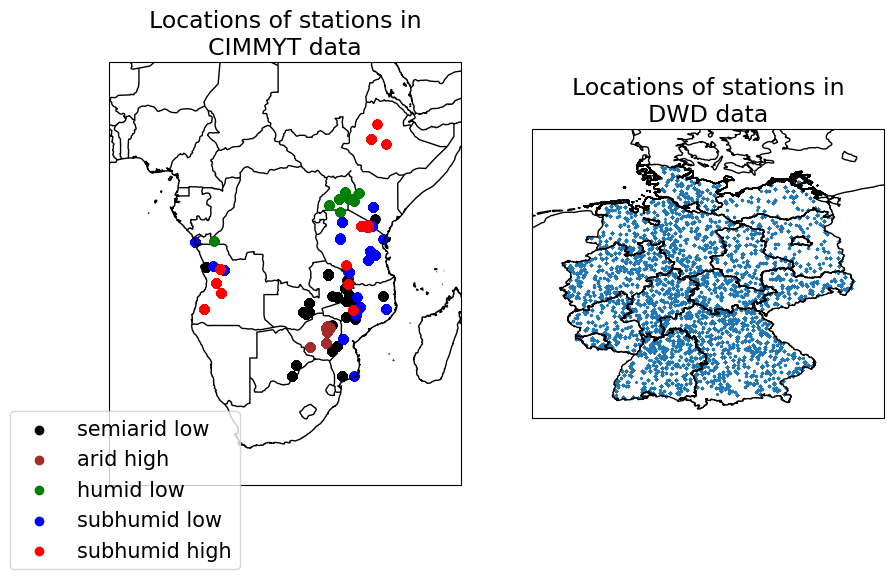

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(10,20), subplot_kw={'projection': ccrs.PlateCarree()})
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
fig, ax = SSA_plot(fig, axs[0])
for i, ds in enumerate(combined_variety_tests_dict.values()):
    print(i)
    ax.scatter(ds['lon'], ds['lat'], color = ['black', 'brown', 'green', 'blue', 'red'][i], label = ['semiarid low', 'arid high', 'humid low', 'subhumid low', 'subhumid high'][i])
ax.legend(bbox_to_anchor=[0.4, 0.2], fontsize = 15)
ax.set_title('Locations of stations in\nCIMMYT data', fontsize = 17)
fig, ax = Germany_plot(fig, axs[1])
ax.scatter(ds_inputs_DE['lon'], ds_inputs_DE['lat'], marker = 'x', s = 2)
ax.set_title('Locations of stations in\nDWD data', fontsize = 17)
fig.savefig('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\plots\\station_locations.png')

In [20]:
combined_variety_tests_dict.keys()

dict_keys(['arid low', 'city', 'arid high', 'humid low', 'humid high'])

In [82]:
no_regions_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
no_regions_test = K_fold_transfer_regions(no_regions_dict, transfer_method='wang and first', index_cols=['Stations_id', 'year'])#'all wang')
results_combined_test = K_fold_transfer_regions(combined_variety_tests_dict, transfer_method='wang and first', index_cols=['Stations_id', 'year'])#'all wang')

early full [0.7016814947128296, 0.7061874866485596, 0.6861416697502136, 0.23992270231246948, 0.6874768137931824]
late full [0.7254036664962769, 0.6005967855453491, 0.6531519889831543, 0.5474591255187988, 0.6339661478996277]
semiarid low [0.6330983638763428, 0.8541276454925537, 0.7606961131095886, 0.7917231321334839, 0.2076926827430725]
arid high [0.09921020269393921, 0.07623177766799927, -0.09440124034881592, -0.26323091983795166, -0.03760218620300293]
humid low [-0.7454981803894043, 0.4641544222831726, 0.5986509323120117, 0.3926553726196289, 0.10200250148773193]
subhumid low [0.47220730781555176, -0.43272721767425537, 0.20943397283554077, 0.7330818176269531, 0.3053162693977356]
humid high [-0.0073882341384887695, -0.7260274887084961, -1.5326685905456543, -0.41302335262298584, -0.3320295810699463]


In [25]:
no_regions_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
#no_regions_test = K_fold_transfer_regions(no_regions_dict, transfer_method='wang and first', index_cols=['Stations_id', 'year'])#'all wang')
results_combined_test = K_fold_transfer_regions(combined_variety_tests_dict, transfer_method='wang and first', index_cols=['Stations_id', 'year'])#'all wang')

Fold:  1
Fold:  2
Fold:  3
Fold:  4
Fold:  5
semiarid low [0.7928417325019836, 0.3777381181716919, 0.8309741616249084, 0.5029211044311523, 0.7653442621231079]
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Fold:  5
arid high [-0.23986029624938965, -0.008507490158081055, 0.18192720413208008, -0.01633930206298828, -0.10650491714477539]
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Fold:  5
humid low [-0.25836610794067383, 0.555802047252655, -1.1525635719299316, 0.3997730016708374, -0.19109952449798584]
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Fold:  5
subhumid low [0.6872460842132568, 0.3732278347015381, 0.28123557567596436, 0.2789585590362549, 0.6306324601173401]
Fold:  1
Fold:  2
Fold:  3
Fold:  4
Fold:  5
humid high [-0.3633831739425659, -0.13309168815612793, 0.46033942699432373, 0.35385018587112427, -0.3413354158401489]


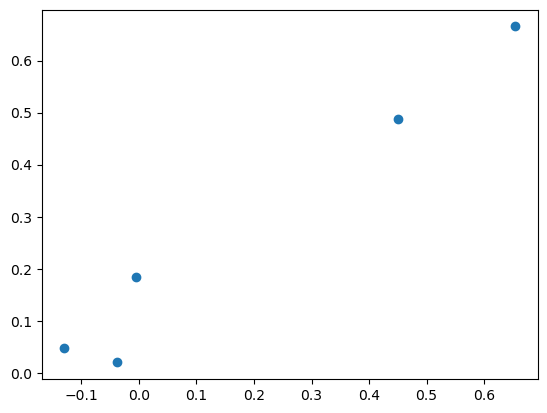

In [36]:
plt.scatter(skill_score_all_reg(results_combined_test)[1].mean(axis=1), skill_score_all_reg(results_combined_test)[2])

In [40]:
comp_scores = pd.DataFrame({'Skill score': np.concatenate([skill_score_all_reg(results_combined_test)[1].mean(axis=1), skill_score_all_reg(results_combined_test)[2]]),
                            'Fold averaging': np.array(['Standard' for count in range(5)] + ['Pooling' for count in range(5)]),
                            'AEZ': list(combined_variety_tests_dict.keys()) + list(combined_variety_tests_dict.keys())})

<Axes: xlabel='AEZ', ylabel='Skill score'>

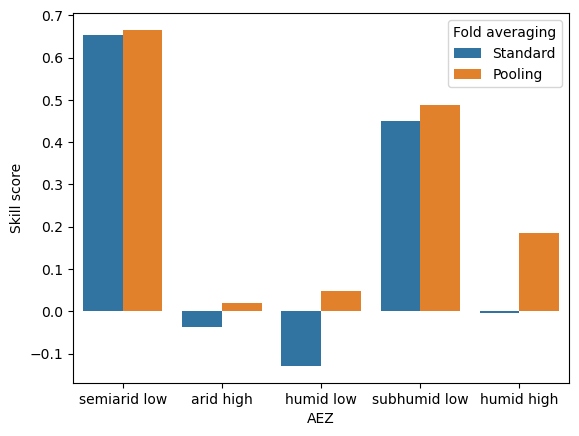

In [42]:
sns.barplot(comp_scores, x = 'AEZ', y = 'Skill score', hue='Fold averaging')

semiarid low
[np.float32(75119.0), np.float32(157098.0), np.float32(43140.0), np.float32(136575.0), np.float32(62644.0)]
RMSEs:  [ 43.0728211  129.51195383  33.703125    85.09345794  38.03521554] 
Variances:  [208.04176330566406, 208.302734375, 199.5517578125, 171.2935791015625, 162.18768310546875] 
R2 scores:  [0.79284192 0.37773831 0.8309738  0.5029206  0.76534394]
arid high
[np.float32(16944.0), np.float32(45808.0), np.float32(25481.0), np.float32(31309.0), np.float32(30438.0)]
RMSEs:  [24.24034335 69.40606061 26.54270833 26.78272027 33.63314917] 
Variances:  [19.578872680664062, 68.92497253417969, 32.47921371459961, 26.374713897705078, 30.42949104309082] 
R2 scores:  [-0.23986054 -0.00850792  0.18192645 -0.01633901 -0.10650401]
humid low
[np.float32(7162.0), np.float32(4297.0), np.float32(25024.0), np.float32(5184.0), np.float32(4050.0)]
RMSEs:  [35.28078818 19.71100917 67.81571816 21.6        20.25      ] 
Variances:  [28.175790786743164, 44.5788688659668, 31.59022331237793, 36.13

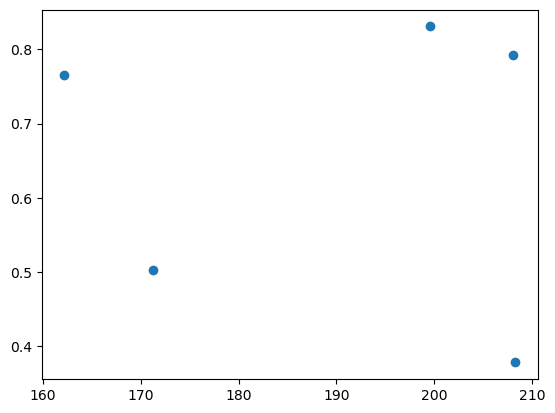

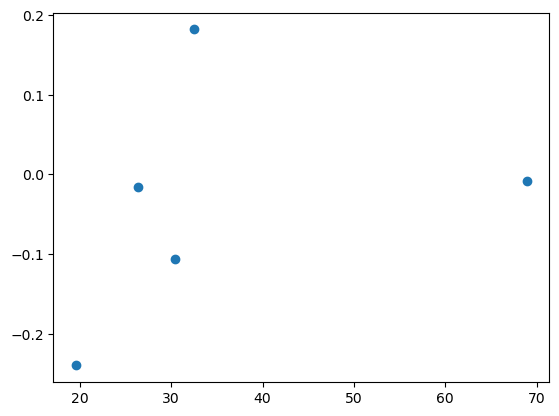

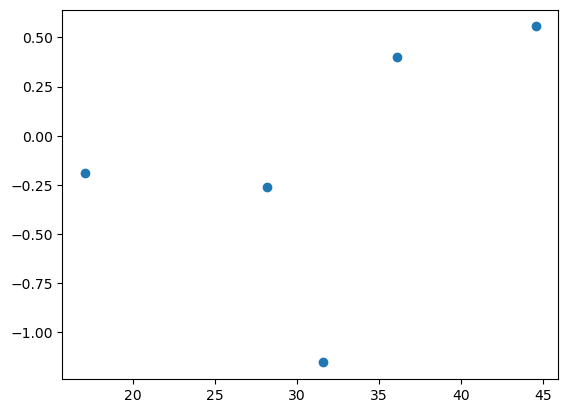

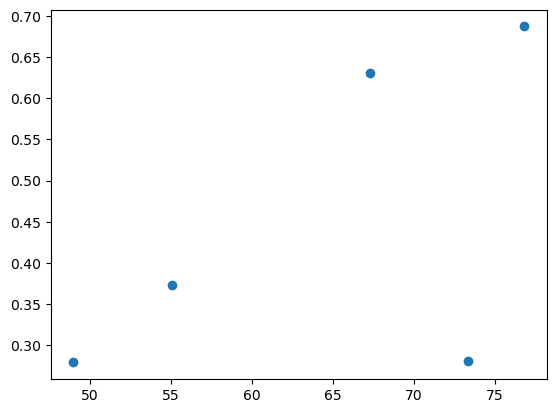

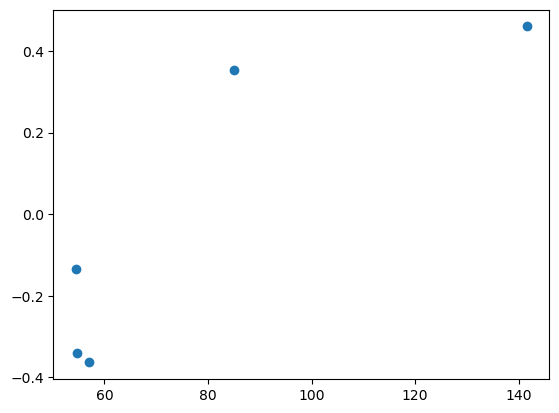

In [33]:
for AEZ_ind, AEZ in enumerate(combined_variety_tests_dict.keys()):
    print(AEZ)
    print(results_combined_test['SSEs'][AEZ_ind])
    RMSEs = np.array(results_combined_test['SSEs'][AEZ_ind])/np.array(results_combined_test['fold lengths'][AEZ_ind])
    R2s = 1 - np.array(results_combined_test['SSEs'][AEZ_ind])/((np.array(results_combined_test['fold lengths'][AEZ_ind]) - 1)*results_combined_test['observed variances'][AEZ_ind])
    obsvars = results_combined_test['observed variances'][AEZ_ind]
    if AEZ_ind == 1:
        obsvars_full = obsvars
        RMSEs_full = RMSEs
        R2s_full = R2s
    elif AEZ_ind == 4:
        obsvars_full = np.concatenate([obsvars, obsvars_full])
        RMSEs_full = np.concatenate([RMSEs, RMSEs_full])
        R2s_full = np.concatenate([R2s, R2s_full])
        
    print('RMSEs: ', RMSEs,
          '\nVariances: ', obsvars,
          '\nR2 scores: ', R2s)
    fig, ax = plt.subplots()
    ax.scatter(obsvars, R2s)

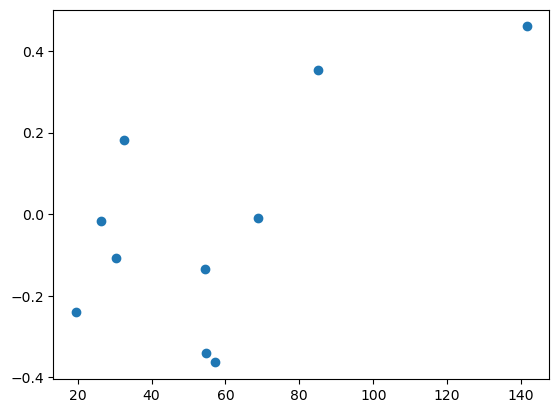

In [34]:
fig, ax = plt.subplots()
ax.scatter(obsvars_full, R2s_full)

In [ ]:
no_regions_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
no_regions_test_indomain = K_fold_transfer_regions(no_regions_dict, transfer_method='in domain', index_cols=['Stations_id', 'year'])#'all wang')
results_combined_test_indomain = K_fold_transfer_regions(combined_variety_tests_dict, transfer_method='in domain', index_cols=['Stations_id', 'year'])#'all wang')

Fold 1
 
 Func-count     x          f(x)          Procedure
    1        1.91601      57.9245        initial
    2        3.09399      62.4333        golden
    3        1.18798      50.6061        golden
    4       0.738031       38.802        golden
    5       0.459948      20.9428        golden
    6       0.288083      16.5598        golden
    7       0.225841      36.3429        parabolic
    8       0.365321      11.6601        parabolic
    9       0.360449      11.3622        parabolic
   10       0.345126      10.7385        parabolic
   11       0.323338      11.2358        golden
   12       0.340899      10.6946        parabolic
   13       0.340267      10.7028        parabolic
   14       0.341929      10.6361        parabolic
   15        0.34315      10.6545        golden
   16       0.342303      10.6445        parabolic
   17       0.341535      10.6368        golden
   18       0.341761      10.6448        parabolic
   19       0.341932      10.6361        parabol

In [40]:
for ind, score_dict in enumerate([results_combined_test_indomain]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['in domain', 'in domain'][ind]
    df_novar, df_novar_pooled, df_novar_full = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_full['region'] = 'all combined'
#df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_novar_pooled = pd.concat([df_novar_full, df_novar_pooled])
df_novar_pooled['Model'] = 'Wageningen in domain'
df_novar_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_pooled_score_Wageningen_indomain.csv')

In [41]:
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_noreg_pooled['Variety'] = ['Early', 'Late']
df_noreg_pooled['Model'] = 'Wageningen in domain'
df_noreg_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_regions_pooled_score_Wageningen_indomain.csv')

In [83]:
for ind, score_dict in enumerate([results_combined_test]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, df_novar_full = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_full['region'] = 'all combined'
#df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_novar_pooled = pd.concat([df_novar_full, df_novar_pooled])
df_novar_pooled['Model'] = 'Wageningen'
df_novar_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_pooled_score_Wageningen.csv')

In [84]:
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test)
df_noreg_pooled['Variety'] = ['Early', 'Late']
df_noreg_pooled['Model'] = 'Wageningen'
df_noreg_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_regions_pooled_score_Wageningen.csv')

In [21]:
for i, comp_frame in enumerate(results_combined_test['comparison_frames']):
    print(results_combined_test['regions'][i],
          r2_score(comp_frame['observed'], comp_frame['fitted']),
          r2_score(comp_frame['observed'], comp_frame['GDD fitted']))

arid low 0.6802372932434082 0.44369959831237793
arid high -0.03081047534942627 -2.448406934738159
humid low 0.5388224720954895 -0.34651923179626465
humid high 0.2614949941635132 -0.41631245613098145


In [ ]:
df, df_pooled, df_full_model = make_df_from_score_dict(results_combined_test_first, TL_method='GDD', variety='combined')

In [ ]:
df_pooled

,R2 score,Variety,TL method
0,0.541327,combined,GDD
1,0.302497,combined,GDD
2,0.188403,combined,GDD
3,0.345718,combined,GDD


In [76]:
#results_dict_early_justrate = K_fold_transfer_regions(early_ds_dict, transfer_method='just rate')
results_dict_early = K_fold_transfer_regions(early_ds_dict, transfer_method='wang and first', index_cols = ['Stations_id', 'year'])#'all wang')
#results_dict_late_justrate = K_fold_transfer_regions(late_ds_dict, transfer_method='just rate')
results_dict_late = K_fold_transfer_regions(late_ds_dict, transfer_method='wang and first', index_cols = ['Stations_id', 'year'])#'all wang')

semiarid low [0.8603342771530151, 0.7918704748153687, 0.859680712223053, 0.793588399887085, -0.7212163209915161]
arid high [-0.3394348621368408, -0.15330016613006592, 0.1498185396194458, -0.27210891246795654, 0.029115378856658936]
humid low [0.317307710647583, 0.6788990497589111, 0.21052628755569458, -0.6714696884155273, -0.21710515022277832]
subhumid low [0.36384469270706177, 0.6026214957237244, 0.7067546844482422, 0.26644641160964966, 0.5679405927658081]
humid high [-0.02605283260345459, 0.1827353835105896, -0.40145230293273926, 0.1151418685913086, -0.7909090518951416]
semiarid low [0.8467012643814087, 0.836681604385376, 0.8314898014068604, 0.6683913469314575, 0.4202396273612976]
arid high [0.004045724868774414, 0.5604395866394043, -0.904761791229248, 0.23954707384109497, -0.03535354137420654]


c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


humid low [-7.282828330993652, -0.6287877559661865, -0.08000004291534424, -50.000003814697266, -1.0199999809265137]
subhumid low [0.5111773610115051, 0.4346121549606323, -0.32352936267852783, 0.4175046682357788, 0.768168032169342]
humid high [-0.054245710372924805, -1.052105188369751, -1.612903118133545, -0.858710765838623, -0.3233681917190552]


In [26]:
#results_dict_early_justrate = K_fold_transfer_regions(early_ds_dict, transfer_method='just rate')
results_dict_early_KG = K_fold_transfer_regions(early_ds_dict, transfer_method='all wang', index_cols = ['Stations_id'])#)'wang and first'
#results_dict_late_justrate = K_fold_transfer_regions(late_ds_dict, transfer_method='just rate')
results_dict_late_KG = K_fold_transfer_regions(late_ds_dict, transfer_method='all wang', index_cols = ['Stations_id'])#)

semiarid low [-0.07558584213256836, 0.3538035750389099, 0.5422236919403076, 0.9292633533477783, -0.1662883758544922]
arid high [0.03277397155761719, -0.09259259700775146, -12.982142448425293, -2.161961793899536, -0.7138643264770508]
humid low [-2.452380895614624, -12.925926208496094, -0.54296875, 0.625, -0.6351351737976074]
subhumid low [0.5601687431335449, 0.1783784031867981, 0.05572444200515747, 0.8040564060211182, -0.23207104206085205]
humid high [-0.6148909330368042, 0.332965612411499, 0.15612101554870605, -0.5493502616882324, -1.4814815521240234]
semiarid low [0.10974806547164917, 0.6664333939552307, -1.2617244720458984, 0.7334609031677246, -0.018329977989196777]
arid high [-1.9897494316101074, -0.1203911304473877, -0.7789335250854492, -0.7051281929016113, -1.0299439430236816]
subhumid low [0.2397150993347168, 0.6724138259887695, -2.7507615089416504, -0.8851145505905151, 0.3127235174179077]
humid high [-0.5202184915542603, 0.4124297499656677, -0.07286429405212402, -1.4000000953674

In [39]:
#results_dict_early_justrate = K_fold_transfer_regions(early_ds_dict, transfer_method='just rate')
results_dict_early_rate = K_fold_transfer_regions(early_ds_dict, transfer_method='just rate', index_cols = ['Stations_id'])#)'wang and first'
#results_dict_late_justrate = K_fold_transfer_regions(late_ds_dict, transfer_method='just rate')
results_dict_late_rate = K_fold_transfer_regions(late_ds_dict, transfer_method='just rate', index_cols = ['Stations_id'])#)

semiarid low [-0.3612881898880005, 0.20385468006134033, -0.029803752899169922, 0.3921968936920166, -2.578319787979126]
arid high [-0.02683103084564209, -0.09259259700775146, -5.4162092208862305, -1.5254089832305908, -0.28023600578308105]


c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\envs\pytorch\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


humid low [-5.714285850524902, -16.037036895751953, -3.511719226837158, 0.0, -0.20270276069641113]
subhumid low [0.3239343762397766, -0.21621620655059814, 0.03546100854873657, 0.34943270683288574, -0.26297831535339355]
humid high [-0.643132209777832, -0.14565610885620117, -0.1368638277053833, -0.9975413084030151, -0.18518519401550293]
semiarid low [-0.2940516471862793, 0.36616450548171997, 0.3134050965309143, 0.14707493782043457, -5.561863899230957]
arid high [-1.0728929042816162, -0.12234640121459961, -1.4343302249908447, -0.7051281929016113, -0.8997213840484619]
subhumid low [-0.017114877700805664, -0.4784482717514038, -1.6954314708709717, -0.26351428031921387, -0.07307112216949463]
humid high [-0.6125681400299072, 0.09284770488739014, 0.08542722463607788, -2.7866666316986084, -3.2919273376464844]


In [ ]:
#results_dict_early_justrate = K_fold_transfer_regions(early_ds_dict, transfer_method='just rate')
results_dict_early = K_fold_transfer_regions(early_ds_dict, transfer_method='wang and first', index_cols = ['Stations_id'])#'all wang')
#results_dict_late_justrate = K_fold_transfer_regions(late_ds_dict, transfer_method='just rate')
results_dict_late = K_fold_transfer_regions(late_ds_dict, transfer_method='wang and first', index_cols = ['Stations_id'])#'all wang')

In [77]:
for ind, score_dict in enumerate([results_dict_early, results_dict_late]):#[results_dict_early_justrate, results_dict_early, results_dict_late_justrate, results_dict_late]):
    variety = ['early', 'late'][ind]
    TL_method = ['Wang and first layer', 'Wang and first layer'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df['region'] = np.array(score_dict['regions'])
    df_pooled['region'] = np.array(score_dict['regions'])
    df_full_model['region'] = 'all combined'
    df_full_model['TL method'] = TL_method
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])

In [80]:
df_pooled_full['TL method'] = TL_method
df_pooled_full

,R2 score,Variety,region,TL method
0,0.659951,early,semiarid low,Wang and first layer
1,0.034162,early,arid high,Wang and first layer
2,0.376317,early,humid low,Wang and first layer
3,0.563472,early,subhumid low,Wang and first layer
4,0.156103,early,humid high,Wang and first layer
0,0.470453,early,all combined,Wang and first layer
0,0.751357,late,semiarid low,Wang and first layer
1,0.180945,late,arid high,Wang and first layer
2,-0.383431,late,humid low,Wang and first layer
3,0.534597,late,subhumid low,Wang and first layer


In [81]:
df_pooled_full['Model'] = 'Wageningen'
df_pooled_full.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_Wageningen_new_split.csv')

In [14]:
def skill_score_all_reg(score_dict):
    SSE_all_reg = np.array(score_dict['SSEs'])
    obsvars_all_reg = np.nan_to_num(np.array(score_dict['observed variances']))
    length_all_reg = np.array(score_dict['fold lengths'])
    MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
    R2_all_reg = 1 - (SSE_all_reg.sum(axis=0)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))
    #R2_pooled = 1 - (SSE_all_reg.sum(axis=1)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=1))
    R2_pooled = []
    for cf in score_dict['comparison_frames']:
        R2_pooled.append(r2_score(cf['observed'], cf['fitted']))
    R2_pooled = np.array(R2_pooled)
    return R2_all_reg, R2_all_reg_split, R2_pooled

def make_df_from_score_dict(score_dict, TL_method = 'NA', variety = 'NA'):
    R2s, R2s_split, R2s_pooled = skill_score_all_reg(score_dict)
    df = pd.DataFrame()
    df['R2 score'] = R2s_split.mean(axis=1)
    df_pooled = pd.DataFrame()
    df_pooled['R2 score'] = R2s_pooled
    df['Variety'] = variety
    df_pooled['Variety'] = variety
    df_full_model = pd.DataFrame()
    df_full_model['Variety'] = [variety]
    df_full_model['R2 score'] = [R2s.mean()]
    return df, df_pooled, df_full_model

In [56]:
score_dict = results_dict_late
SSE_all_reg = np.array(score_dict['SSEs'])
obsvars_all_reg = np.nan_to_num(np.array(score_dict['observed variances']))
length_all_reg = np.array(score_dict['fold lengths'])
MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
R2_all_reg = 1 - (SSE_all_reg.sum()/((length_all_reg - 1)*obsvars_all_reg).sum())
R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))
#R2_pooled = 1 - (SSE_all_reg.sum(axis=1)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=1))
R2_pooled = []
for cf in score_dict['comparison_frames']:
    R2_pooled.append(r2_score(cf['observed'], cf['fitted']))

R2_pooled = np.array(R2_pooled)

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_11100\3311247977.py:7: RuntimeWarning: divide by zero encountered in divide
  R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))


In [57]:
results_dict_late['regions']

['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high']

In [58]:
score_dict['comparison_frames'][2]

,fitted,observed,GDD fitted,Error
0,71.0,68.0,65.0,-3.0
1,71.0,68.0,65.0,-3.0
0,71.0,-88.0,66.0,-159.0
0,74.0,72.0,67.0,-2.0
1,73.0,72.0,67.0,-1.0
2,74.0,76.0,67.0,2.0
3,73.0,72.0,67.0,-1.0
0,70.0,78.0,64.0,8.0
1,70.0,68.0,64.0,-2.0
2,70.0,67.0,64.0,-3.0


In [44]:
((length_all_reg - 1)*obsvars_all_reg).sum(axis=0)

array([2836.13098526, 4514.13424969,  964.02637434, 7971.02780342,
       3176.96554947])

In [46]:
R2_all_reg

np.float64(-0.9500793495603066)

In [35]:
for ind, score_dict in enumerate([results_dict_late]):#results_dict_early, [results_dict_early_justrate, results_dict_early, results_dict_late_justrate, results_dict_late]):
    variety = ['late', 'late'][ind]
    TL_method = ['Wang and first layer', 'Wang and first layer'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df['region'] = np.array(score_dict['regions'])
    df_pooled['region'] = np.array(score_dict['regions'])
    df_full_model['region'] = 'all combined'
    df_full_model['TL method'] = TL_method
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_16768\1566368759.py:7: RuntimeWarning: divide by zero encountered in divide
  R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))


In [36]:
df_pooled_full

,R2 score,Variety,region,TL method
0,0.687050,late,semiarid low,NaN
1,-1.330546,late,arid high,NaN
2,-0.056700,late,humid low,NaN
3,0.245524,late,subhumid low,NaN
4,0.134753,late,humid high,NaN
0,-0.893637,late,all combined,Wang and first layer


In [43]:
df_pooled_full2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_Wageningen_new_split.csv')
df_pooled_full['Model'] = 'Wageningen'
df_pooled_full2 = df_pooled_full2.loc[df_pooled_full2['Variety'] == 'early']
df_pooled_full2 = pd.concat([df_pooled_full, df_pooled_full2])

In [44]:
df_pooled_full2

,R2 score,Variety,region,TL method,Model,Unnamed: 0
0,0.687050,late,semiarid low,NaN,Wageningen,NaN
1,-1.330546,late,arid high,NaN,Wageningen,NaN
2,-0.056700,late,humid low,NaN,Wageningen,NaN
3,0.245524,late,subhumid low,NaN,Wageningen,NaN
4,0.134753,late,humid high,NaN,Wageningen,NaN
0,-0.893637,late,all combined,Wang and first layer,Wageningen,NaN
0,0.649747,early,semiarid low,Wang and first layer,Wageningen,0.0
1,-1.068444,early,arid high,Wang and first layer,Wageningen,1.0
2,0.282585,early,humid low,Wang and first layer,Wageningen,2.0
3,0.366619,early,subhumid low,Wang and first layer,Wageningen,3.0


In [45]:
df_pooled_full['Model'] = 'Wageningen'
df_pooled_full2.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_Wageningen_new_split.csv')

In [14]:
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test)
df_noreg_pooled['Variety'] = ['Early', 'Late']
for ind, score_dict in enumerate([results_combined_test]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, ____ = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled['region'] = score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])

In [16]:
df_noreg_pooled

,R2 score,Variety,TL method
0,0.628517,Early,NA
1,0.648140,Late,NA


In [18]:
df_novar_pooled

,R2 score,Variety,TL method,region
0,0.680237,combined,first,arid low
1,-0.030810,combined,first,arid high
2,0.538822,combined,first,humid low
3,0.261495,combined,first,humid high


In [19]:
for ind, score_dict in enumerate([results_dict_early, results_dict_late]):#[results_dict_early_justrate, results_dict_early, results_dict_late_justrate, results_dict_late]):
    variety = ['early', 'early', 'late', 'late'][ind]
    TL_method = ['just rate', 'all Wang', 'just rate', 'all Wang'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df['region'] = np.array(score_dict['regions'])
    df_pooled['region'] = np.array(score_dict['regions'])
    df_full_model['region'] = 'all combined'
    df_full_model['TL method'] = TL_method
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])


In [20]:
df_pooled_full

,R2 score,Variety,TL method,region
0,0.660290,early,just rate,arid low
1,-0.005169,early,just rate,arid high
2,0.562104,early,just rate,humid low
3,0.245931,early,just rate,humid high
0,0.552313,early,just rate,all combined
0,0.788797,early,all Wang,arid low
1,-0.170049,early,all Wang,arid high
2,0.478290,early,all Wang,humid low
3,0.117657,early,all Wang,humid high
0,0.552640,early,all Wang,all combined


In [ ]:
df_full

,R2 score,Variety,TL method,region
0,0.338745,early,just rate,arid low
1,-2.132096,early,just rate,city
2,-0.059906,early,just rate,high
3,0.131749,early,just rate,humid low
0,0.118099,early,just rate,all combined
0,0.572409,early,all Wang,arid low
1,0.061416,early,all Wang,city
2,-0.016361,early,all Wang,high
3,0.398828,early,all Wang,humid low
0,0.446160,early,all Wang,all combined


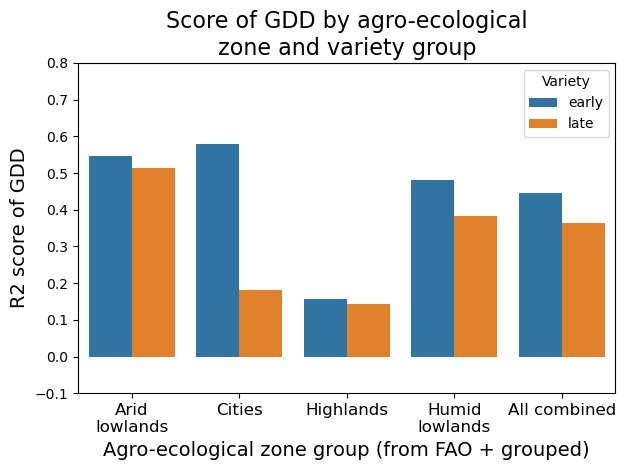

In [ ]:
font_size = 14
fig, ax = plt.subplots()
sns.barplot(data = df_pooled_full.loc[df_pooled_full['TL method'] == 'all Wang'], hue = 'Variety', x = 'region', y='R2 score', ax=ax)
ax.set_xticks(range(5), ['Arid\nlowlands', 'Cities', 'Highlands', 'Humid\nlowlands', 'All combined'], fontsize =font_size - 2)
ax.set_ylabel('R2 score of GDD', fontsize =font_size)
ax.set_xlabel('Agro-ecological zone group (from FAO + grouped)', fontsize =font_size)
ax.set_title('Score of GDD by agro-ecological\nzone and variety group', fontsize = font_size +2)
ax.set_ylim((-0.1, 0.8))
fig.tight_layout()

In [15]:
#train_ds, val_ds = train_test_ds_from_tensors(temp_NDVI_series_SSA, NDVI_labels_SSA, train_proportion=1)
bs = 30000
n_channels = 5
#temp_NDVI_series_DE = torch.swapaxes(torch.stack((temp_series_DE, photoperiod_series_DE, NDVI_series_DE)), 0, 1) #photoperiod_series_DE,
#temp_NDVI_series_DE = torch.swapaxes(temp_NDVI_series_DE, 2, 1)[2022, 2023, 2024]
#train_dl, val_dl = train_test_dl_from_tensors(temp_NDVI_series_DE, NDVI_labels_DE, bs = bs, n_channels = n_channels, train_proportion=0.8)
#train_dl, val_dl = train_test_dl_by_year(temp_NDVI_series_DE, NDVI_labels_DE, test_years = [2023, 2024], year_column = -2, bs = bs, n_channels = n_channels, train_proportion=0.8)
input_dim = n_channels # Example: 100-dimensional word embeddings
hidden_dim = 16#day2 -> 8#day -> 16 #day3 ->4
num_layers = 4#day3 -> 8
output_dim = 1  # Example: 5 classes
KG = False
KG2 = True
CNN = False
bce=True

model_args = (input_dim, hidden_dim, num_layers, output_dim, KG, KG2)
save_name = 'NN_response_DE_no_day5_more_epochs'

epochs = 500
lr=0.01
#run K-fold cross validation
criterion = problist_square_loss()
comparison_frame, loss_values, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = K_fold_transfer(5, late_ds_dict['subhumid low'], nn_temp_response, 
                                                                                                        save_name, epochs, bs, model_args, lr = lr, savename_prefix='subhumid_resp_TL',#'semiarid_resp_TL',
                                                                                                        loss = 'MSE', CNN=CNN, bce=bce, 
                                                                                                        custom_loss=criterion, DTF = False, transfer_method = 'wang and first',
                                                                                                        verbose=True, index_cols=['Stations_id'])

c:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\ML_algorithms\nn_response_fctns.py:131: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\b\abs_34s6o8i12c\croot\libtorch_1751464457133\work\torch\csrc\utils\tensor_new.cpp:257.)
  year_series = torch.Tensor([ds['year'].values for count in range(numsteps)]).T


0 25.92668914794922 17.79514503479004
1 24.533443450927734 16.996139526367188
2 23.370849609375 16.198820114135742
48 15.102842330932617 10.0510835647583
49 15.034989356994629 10.004724502563477
50 14.96503734588623 9.950430870056152
51 14.895039558410645 9.890410423278809
52 14.827241897583008 9.833625793457031
98 12.564835548400879 8.003841400146484
99 12.53564453125 7.974467754364014
100 12.506864547729492 7.946262359619141
101 12.478507041931152 7.918545246124268
102 12.450620651245117 7.890594482421875
148 11.553732872009277 6.9004011154174805
149 11.540663719177246 6.8847432136535645
150 11.527786254882812 6.869340419769287
151 11.515104293823242 6.854155540466309
152 11.502617835998535 6.839168071746826
198 11.082879066467285 6.32639217376709
199 11.076181411743164 6.318203449249268
200 11.069559097290039 6.310121536254883
201 11.063010215759277 6.302143096923828
202 11.056527137756348 6.294241905212402
248 10.81121826171875 6.012042045593262
249 10.806626319885254 6.00723552703

In [64]:
comparison_frame

,fitted,observed,GDD fitted,Error
0,74.0,68.0,73.0,-6.0
1,74.0,68.0,73.0,-6.0
0,74.0,-88.0,73.0,-162.0
0,75.0,72.0,73.0,-3.0
1,75.0,72.0,73.0,-3.0
2,76.0,76.0,74.0,0.0
3,75.0,72.0,73.0,-3.0
0,75.0,67.0,74.0,-8.0
1,74.0,64.0,72.0,-10.0
2,75.0,72.0,74.0,-3.0


In [62]:
R2s

[-1.25,
 -0.6058393716812134,
 -0.5535714626312256,
 -2.843750238418579,
 -0.15979373455047607]

In [38]:
r2_score(comparison_frame['observed'], comparison_frame['fitted'])

0.1936587691307068

In [33]:
R2s

[0.8179190754890442,
 -0.4984227418899536,
 0.7176591157913208,
 0.3643263578414917,
 0.8127753734588623]

In [ ]:
np.mean(np.array(R2s))

np.float64(0.5425811648368836)

In [ ]:
r2_score(comparison_frame['observed'], comparison_frame['fitted'])

0.5504122972488403

In [ ]:
r2_score(comparison_frame['observed'], comparison_frame['fitted'])

0.27426183223724365